<a href="https://colab.research.google.com/github/Nutchayapon/Super_AI_Engineer-SS.6/blob/main/Mini_Hackathon2_601661.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini-Hackathon2 : Thai Election OCR Kaggle Competition**

จัดทำโดย

รหัส: 601661

ชื่อ-นามสกุล: ณัชยภรณ์ คันธรส

In [ ]:
# ============================================================
# Cell 1: Imports & โหลดข้อมูล
# ============================================================
import cv2
import re
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-season-6-ocr-2569
!unzip -q super-ai-engineer-season-6-ocr-2569.zip -d data/

data_dir    = "data/"
all_files   = glob.glob(os.path.join(data_dir, "**/*"), recursive=True)
image_files = [f for f in all_files if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))]
print(f"จำนวนไฟล์ภาพทั้งหมด: {len(image_files)}")
for f in image_files[:10]:
    print(" ", f)

100% 474M/474M [00:30<00:00, 16.4MB/s]

จำนวนไฟล์ภาพทั้งหมด: 846
  data/final_data/images/constituency_11_8_page2.png
  data/final_data/images/party_list_20_8_page3.png
  data/final_data/images/party_list_24_3_page4.png
  data/final_data/images/party_list_31_10_page2.png
  data/final_data/images/party_list_24_1_page3.png
  data/final_data/images/constituency_31_6_page2.png
  data/final_data/images/party_list_10_16_page2.png
  data/final_data/images/party_list_12_3_page3.png
  data/final_data/images/constituency_33_7_page2.png
  data/final_data/images/party_list_10_29_page2.png


In [ ]:
df_answer = pd.read_csv("submission_template_v3.csv")
df_answer.shape

(10053, 3)

In [ ]:
# ============================================================
# Cell 2: ฟังก์ชันแปลงเลขไทย -> อารบิก
# ============================================================
def clean_and_convert_to_arabic(text):
    thai_nums   = '๐๑๒๓๔๕๖๗๘๙'
    arabic_nums = '0123456789'
    translation_table = str.maketrans(thai_nums, arabic_nums)
    text_arabic  = text.translate(translation_table)
    text_cleaned = text_arabic.replace(',', '').replace(' ', '')
    numbers      = re.findall(r'\d+', text_cleaned)
    if numbers:
        return int(numbers[0])
    return None

# ทดสอบ
print(clean_and_convert_to_arabic("๑,๒๓๔"))  # -> 1234
print(clean_and_convert_to_arabic("5,678"))   # -> 5678

1234
5678


In [ ]:
# ============================================================
# Cell 3: Parse ชื่อไฟล์ -> (type, เขต, รูป, page)
# ============================================================
def parse_filename(filename):
    """
    constituency_10_1.png       -> ('constituency', '10', '1', 1)
    constituency_10_1_page2.png -> ('constituency', '10', '1', 2)
    party_list_10_1.png         -> ('party_list', '10', '1', 1)
    party_list_10_1_page2.png   -> ('party_list', '10', '1', 2)
    """
    name = os.path.splitext(filename)[0]

    page_match   = re.search(r'_page(\d+)$', name)
    page         = int(page_match.group(1)) if page_match else 1
    name_no_page = re.sub(r'_page\d+$', '', name)

    # constituency
    m = re.match(r'^constituency_(\d+)_(\d+)$', name_no_page)
    if m:
        return ('constituency', m.group(1), m.group(2), page)

    # party_list
    m = re.match(r'^party_list_(\d+)_(\d+)$', name_no_page)
    if m:
        return ('party_list', m.group(1), m.group(2), page)

    return None

# ทดสอบ
print(parse_filename("constituency_10_1.png"))        # -> ('constituency', '10', '1', 1)
print(parse_filename("constituency_10_1_page2.png"))  # -> ('constituency', '10', '1', 2)
print(parse_filename("party_list_10_1.png"))          # -> ('party_list', '10', '1', 1)
print(parse_filename("party_list_10_1_page2.png"))    # -> ('party_list', '10', '1', 2)

('constituency', '10', '1', 1)
('constituency', '10', '1', 2)
('party_list', '10', '1', 1)
('party_list', '10', '1', 2)


พบรูปภาพทั้งหมด: 846 ไฟล์
Intersection threshold: 20


สแกนรูปภาพ: 100%|██████████| 846/846 [04:09<00:00,  3.40it/s]
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3


📊  สรุปผลการกรองรูปภาพ
  รูปทั้งหมด               :   846
  parse ชื่อไฟล์ไม่ได้ (ข้าม):     0
  ✅  เก็บไว้ (มีตาราง)     :   652  (77.1%)
  ❌  ตัดออก (ไม่มีตาราง)   :   194  (22.9%)
------------------------------------------------------------
  แบบบัญชีรายชื่อ (party_list):
      เก็บ  432  |  ตัดออก   99
  แบบแบ่งเขต (constituency):
      เก็บ  220  |  ตัดออก   95

  จุดตัดเฉลี่ย (หน้าที่เก็บ)  : 89.5  (min=20, max=233)
  จุดตัดเฉลี่ย (หน้าที่ตัดออก): 7.4  (min=0, max=19)

รายชื่อไฟล์ที่ถูกตัดออกทั้งหมด (194 ไฟล์):
  constituency_10_1.png                          จุดตัด:   4  [constituency]
  constituency_10_10.png                         จุดตัด:   6  [constituency]
  constituency_10_11_page3.png                   จุดตัด:   6  [constituency]
  constituency_10_12.png                         จุดตัด:   5  [constituency]
  constituency_10_12_page3.png                   จุดตัด:   8  [constituency]
  constituency_10_13.png                         จุดตัด:   9  [constituency]
  constituency

/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3655 (\N{THAI CHARACTER MAITAIKHU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:199: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font

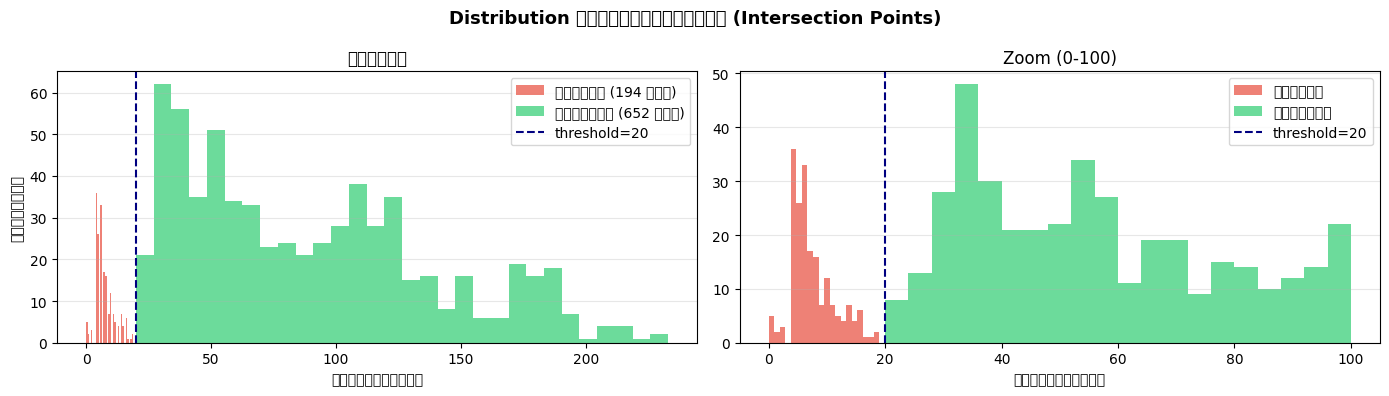

บันทึก histogram -> table_filter_histogram.png


/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:240: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.


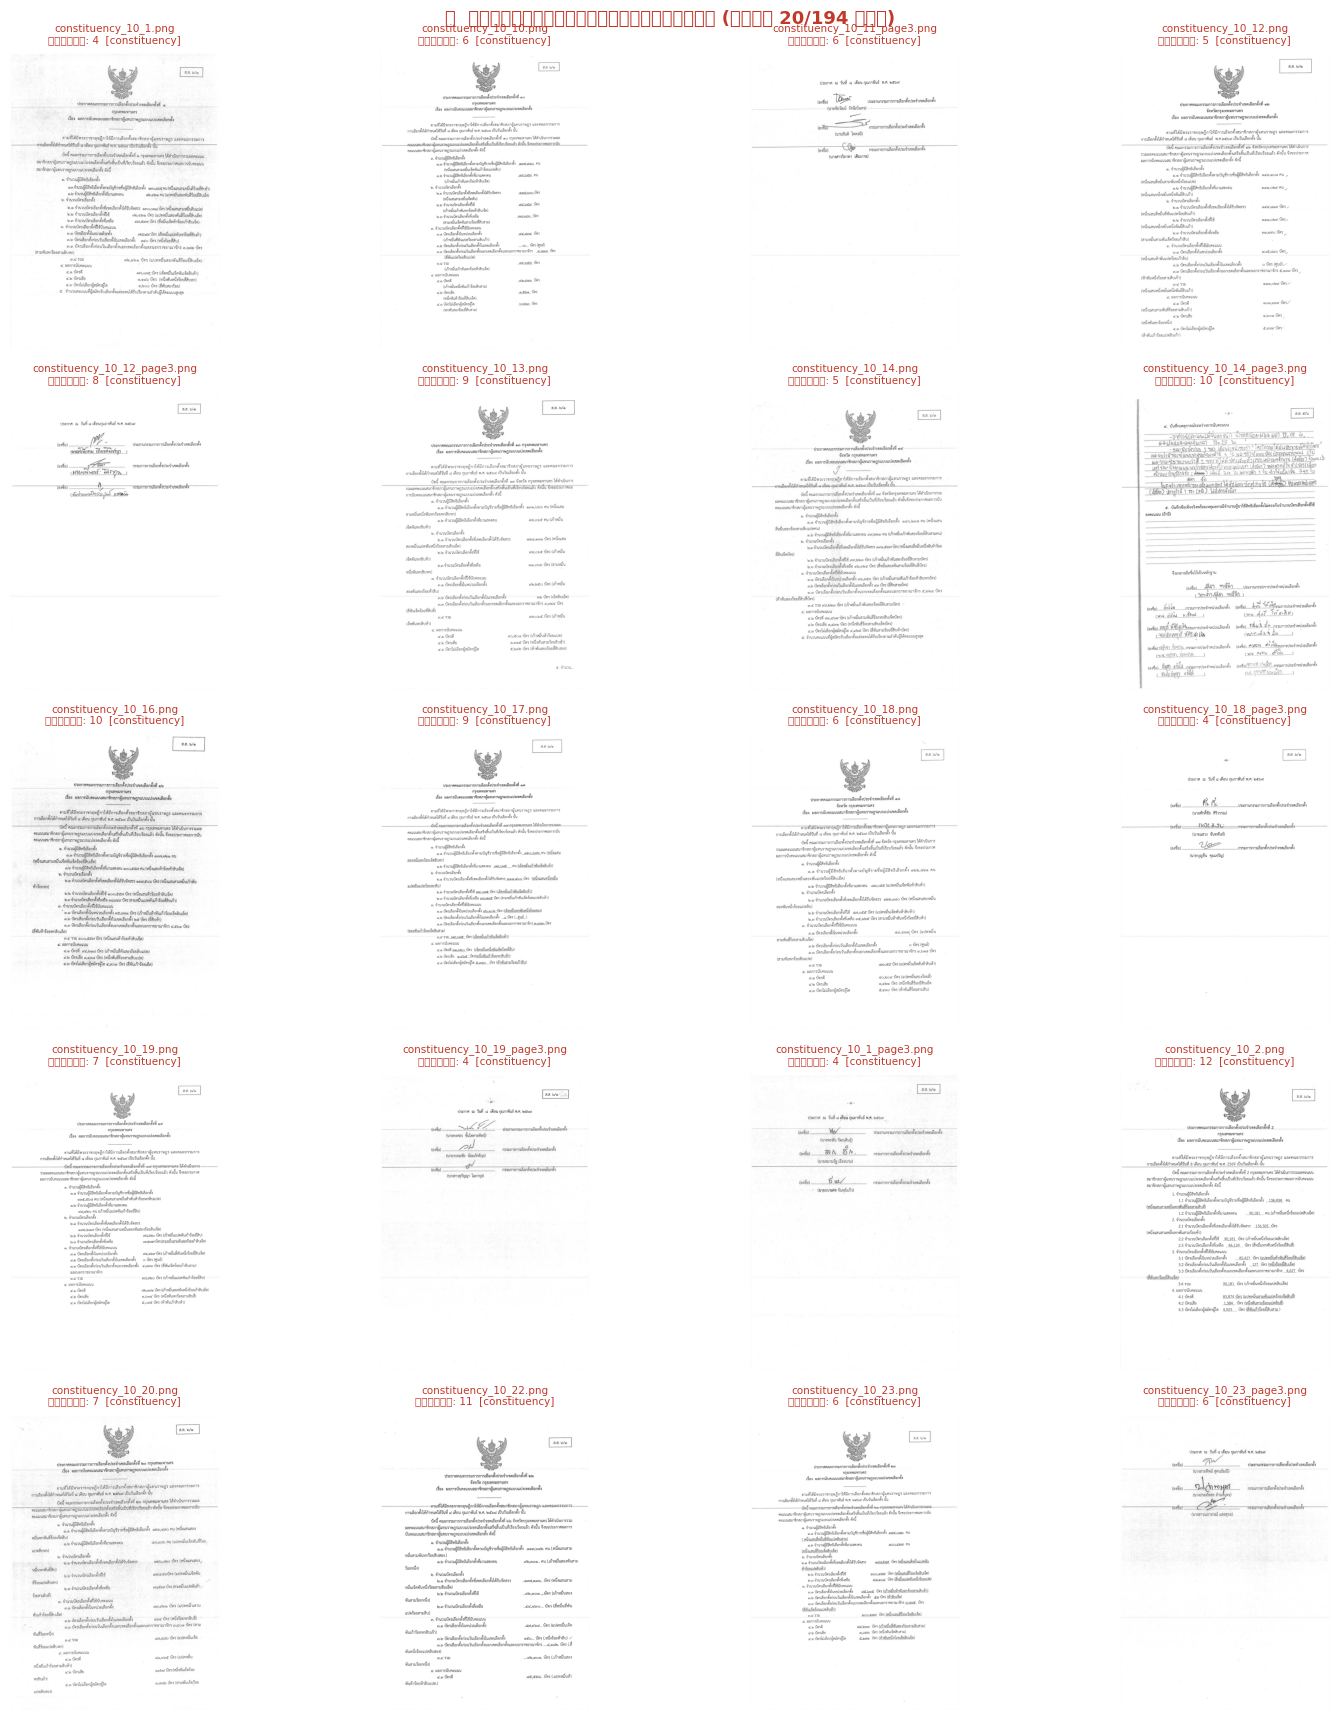

บันทึกตัวอย่างรูปที่ตัดออก -> rejected_samples.png


/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:281: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) De

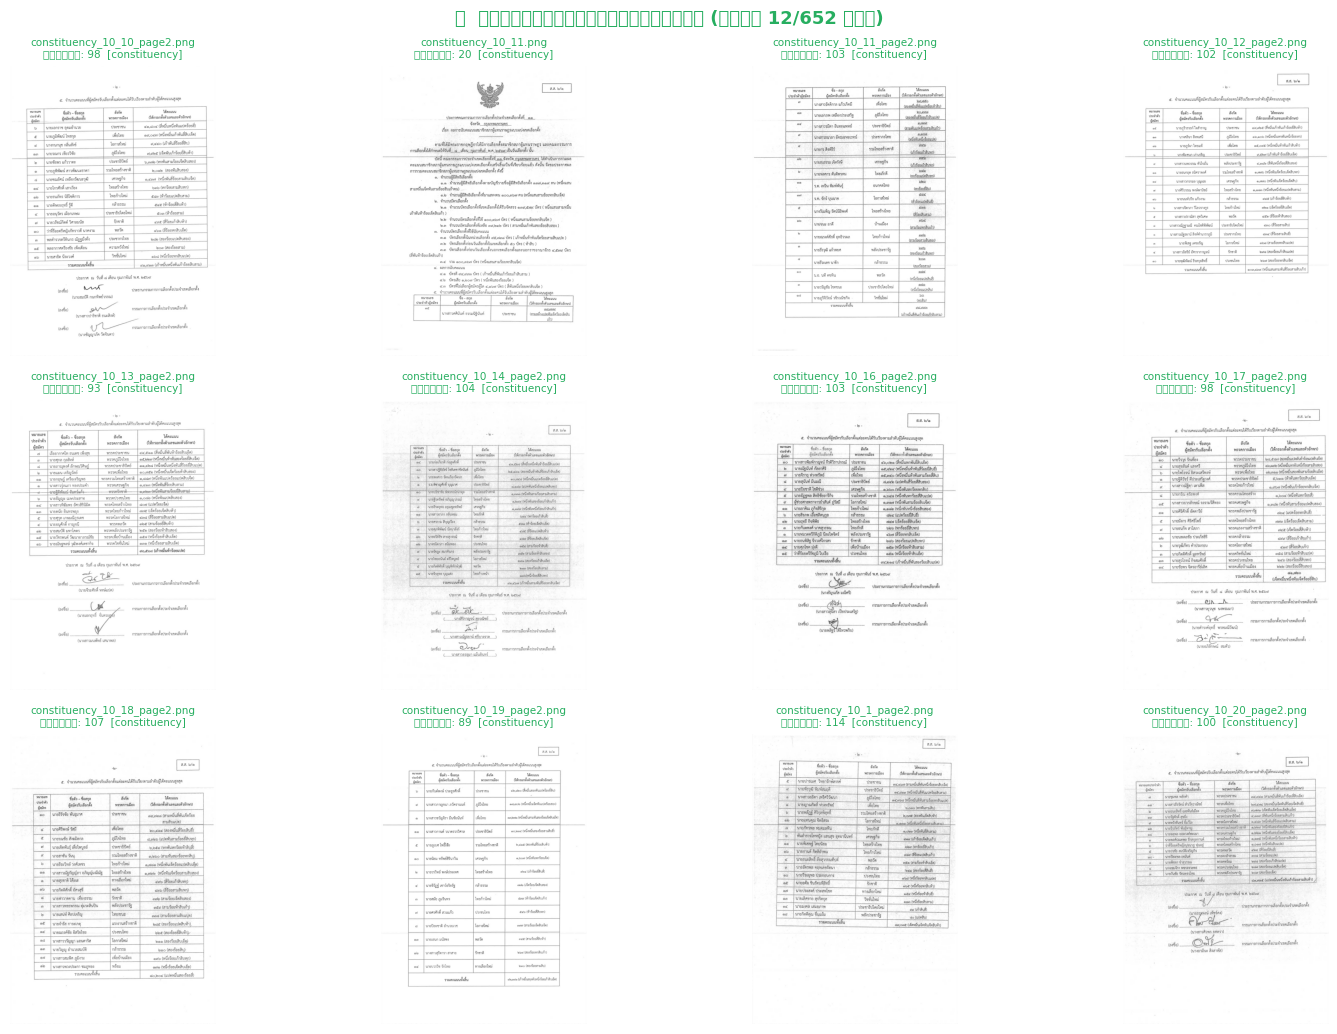

บันทึกตัวอย่างรูปที่เก็บไว้ -> kept_samples.png


/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1256/1272408259.py:346: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  

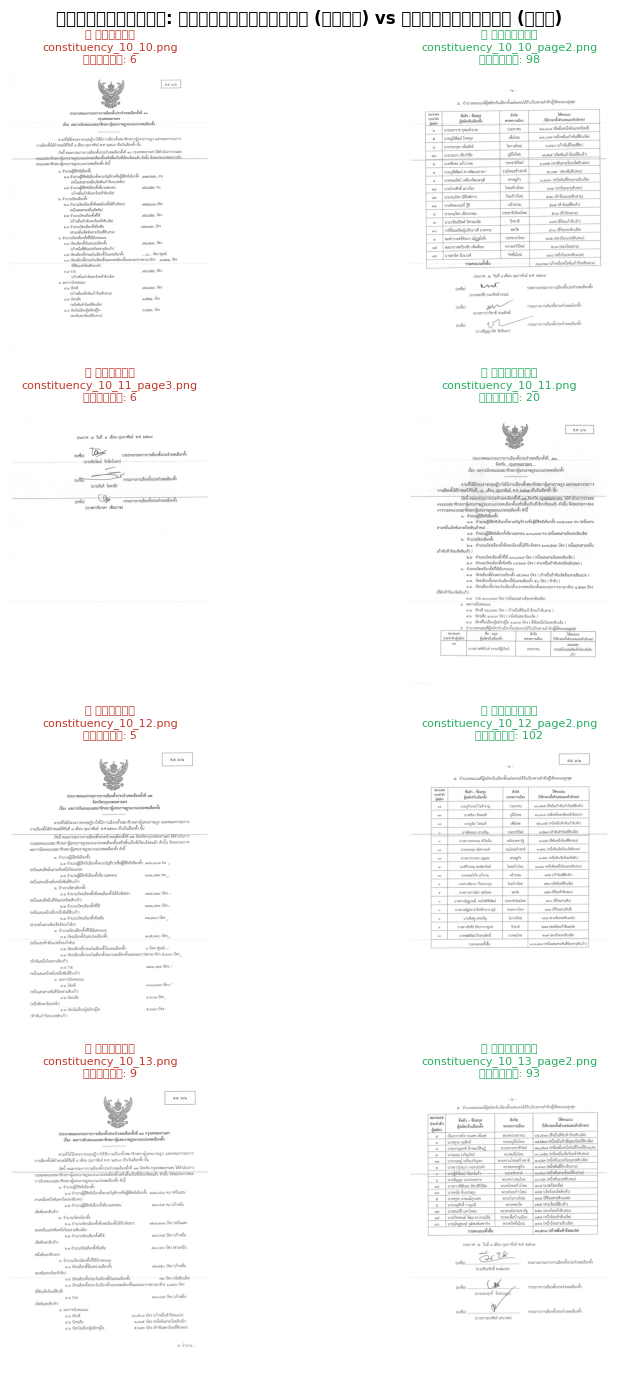

บันทึกการเปรียบเทียบ -> side_by_side_comparison.png


In [ ]:
# ============================================================
# Cell 4A + 4B: ตรวจสอบการกรองตารางจากทุกภาพ
# พร้อมพิมพ์สรุปและแสดงตัวอย่างภาพที่ถูกตัดออก
# ============================================================

import cv2
import re
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from collections import defaultdict


# ------------------------------------------------------------------
# 4A: ฟังก์ชันตรวจสอบตาราง (เหมือนเดิม)
# ------------------------------------------------------------------
def is_table_document_improved(image_path, intersection_threshold=20):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False, 0

    h, w = img.shape
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 51, 10
    )

    dilate_kernel = np.ones((3, 3), np.uint8)
    thresh_dilated = cv2.dilate(thresh, dilate_kernel, iterations=1)

    horizontal_size = max(15, w // 60)
    vertical_size   = max(15, h // 60)

    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horizontal_size, 1))
    vertical_kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vertical_size))

    horizontal_lines = cv2.morphologyEx(thresh_dilated, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
    vertical_lines   = cv2.morphologyEx(thresh_dilated, cv2.MORPH_OPEN, vertical_kernel, iterations=1)

    intersections = cv2.bitwise_and(horizontal_lines, vertical_lines)
    contours, _ = cv2.findContours(intersections, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_intersections = len(contours)

    line_pixels = cv2.countNonZero(horizontal_lines) + cv2.countNonZero(vertical_lines)
    is_table = (num_intersections >= intersection_threshold) and (line_pixels > (h * w * 0.0005))

    return is_table, num_intersections


# ------------------------------------------------------------------
# helper: parse filename
# ------------------------------------------------------------------
def parse_filename(filename):
    name = os.path.splitext(filename)[0]
    page_match   = re.search(r'_page(\d+)$', name)
    page         = int(page_match.group(1)) if page_match else 1
    name_no_page = re.sub(r'_page\d+$', '', name)

    m = re.match(r'^constituency_(\d+)_(\d+)$', name_no_page)
    if m:
        return ('constituency', m.group(1), m.group(2), page)

    m = re.match(r'^party_list_(\d+)_(\d+)$', name_no_page)
    if m:
        return ('party_list', m.group(1), m.group(2), page)

    return None


# ------------------------------------------------------------------
# 4B: สแกนทุกภาพ + จัดกลุ่ม
# ------------------------------------------------------------------
def scan_all_images(data_dir="/content/data/4_1_1_original", threshold=20):
    all_files = glob.glob(os.path.join(data_dir, "**/*"), recursive=True)
    image_files = sorted([
        f for f in all_files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ])

    print(f"พบรูปภาพทั้งหมด: {len(image_files)} ไฟล์")
    print(f"Intersection threshold: {threshold}")
    print("=" * 60)

    kept     = []   # (path, intersections, doc_type)
    rejected = []   # (path, intersections, doc_type)
    skipped_parse = []

    for filepath in tqdm(image_files, desc="สแกนรูปภาพ"):
        filename  = os.path.basename(filepath)
        parsed    = parse_filename(filename)

        if parsed is None:
            skipped_parse.append(filepath)
            continue

        doc_type = parsed[0]
        is_table, pts = is_table_document_improved(filepath, threshold)

        entry = (filepath, pts, doc_type)
        if is_table:
            kept.append(entry)
        else:
            rejected.append(entry)

    return kept, rejected, skipped_parse, image_files


# ------------------------------------------------------------------
# พิมพ์สรุปผล
# ------------------------------------------------------------------
def print_summary(kept, rejected, skipped_parse, image_files):
    total = len(image_files)
    n_kept     = len(kept)
    n_rejected = len(rejected)
    n_skipped  = len(skipped_parse)

    # แยกตาม doc_type
    kept_party   = [x for x in kept     if x[2] == "party_list"]
    kept_const   = [x for x in kept     if x[2] == "constituency"]
    rej_party    = [x for x in rejected if x[2] == "party_list"]
    rej_const    = [x for x in rejected if x[2] == "constituency"]

    print("\n" + "=" * 60)
    print("📊  สรุปผลการกรองรูปภาพ")
    print("=" * 60)
    print(f"  รูปทั้งหมด               : {total:>5}")
    print(f"  parse ชื่อไฟล์ไม่ได้ (ข้าม): {n_skipped:>5}")
    print(f"  ✅  เก็บไว้ (มีตาราง)     : {n_kept:>5}  "
          f"({n_kept/(total-n_skipped)*100:.1f}%)")
    print(f"  ❌  ตัดออก (ไม่มีตาราง)   : {n_rejected:>5}  "
          f"({n_rejected/(total-n_skipped)*100:.1f}%)")
    print("-" * 60)
    print(f"  แบบบัญชีรายชื่อ (party_list):")
    print(f"      เก็บ {len(kept_party):>4}  |  ตัดออก {len(rej_party):>4}")
    print(f"  แบบแบ่งเขต (constituency):")
    print(f"      เก็บ {len(kept_const):>4}  |  ตัดออก {len(rej_const):>4}")
    print("=" * 60)

    # distribution ของ intersection points
    all_pts_kept = [x[1] for x in kept]
    all_pts_rej  = [x[1] for x in rejected]
    if all_pts_kept:
        print(f"\n  จุดตัดเฉลี่ย (หน้าที่เก็บ)  : {np.mean(all_pts_kept):.1f}  "
              f"(min={min(all_pts_kept)}, max={max(all_pts_kept)})")
    if all_pts_rej:
        print(f"  จุดตัดเฉลี่ย (หน้าที่ตัดออก): {np.mean(all_pts_rej):.1f}  "
              f"(min={min(all_pts_rej)}, max={max(all_pts_rej)})")

    if skipped_parse:
        print(f"\n  ไฟล์ที่ parse ชื่อไม่ได้ ({n_skipped} ไฟล์):")
        for f in skipped_parse[:10]:
            print(f"    - {os.path.basename(f)}")
        if n_skipped > 10:
            print(f"    ... และอีก {n_skipped-10} ไฟล์")


# ------------------------------------------------------------------
# วาด histogram intersection points
# ------------------------------------------------------------------
def plot_intersection_histogram(kept, rejected):
    pts_kept = [x[1] for x in kept]
    pts_rej  = [x[1] for x in rejected]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("Distribution ของจำนวนจุดตัด (Intersection Points)", fontsize=13, fontweight="bold")

    # histogram รวม
    ax = axes[0]
    ax.hist(pts_rej,  bins=30, color="#e74c3c", alpha=0.7, label=f"ตัดออก ({len(pts_rej)} รูป)")
    ax.hist(pts_kept, bins=30, color="#2ecc71", alpha=0.7, label=f"เก็บไว้ ({len(pts_kept)} รูป)")
    ax.axvline(x=20, color="navy", linestyle="--", linewidth=1.5, label="threshold=20")
    ax.set_xlabel("จำนวนจุดตัด")
    ax.set_ylabel("จำนวนรูป")
    ax.set_title("ภาพรวม")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # zoom ที่ zone ใกล้ threshold
    ax2 = axes[1]
    all_pts = pts_kept + pts_rej
    zoom_max = min(100, max(all_pts) if all_pts else 100)
    pts_rej_zoom  = [p for p in pts_rej  if p <= zoom_max]
    pts_kept_zoom = [p for p in pts_kept if p <= zoom_max]
    ax2.hist(pts_rej_zoom,  bins=20, color="#e74c3c", alpha=0.7, label=f"ตัดออก")
    ax2.hist(pts_kept_zoom, bins=20, color="#2ecc71", alpha=0.7, label=f"เก็บไว้")
    ax2.axvline(x=20, color="navy", linestyle="--", linewidth=1.5, label="threshold=20")
    ax2.set_xlabel("จำนวนจุดตัด")
    ax2.set_title(f"Zoom (0-{zoom_max})")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("table_filter_histogram.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("บันทึก histogram -> table_filter_histogram.png")


# ------------------------------------------------------------------
# แสดงตัวอย่างรูปที่ถูก "ตัดออก" (grid)
# ------------------------------------------------------------------
def plot_rejected_samples(rejected, max_show=20):
    if not rejected:
        print("ไม่มีรูปถูกตัดออกเลย!")
        return

    n = min(max_show, len(rejected))
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    fig.suptitle(f"❌  ตัวอย่างภาพที่ถูกตัดออก (แสดง {n}/{len(rejected)} รูป)",
                 fontsize=13, fontweight="bold", color="#c0392b")

    axes_flat = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i in range(len(axes_flat)):
        ax = axes_flat[i]
        if i < n:
            path, pts, doc_type = rejected[i]
            try:
                img = Image.open(path)
                ax.imshow(img, cmap="gray")
            except Exception:
                ax.text(0.5, 0.5, "ไม่สามารถเปิดรูปได้",
                        ha="center", va="center", transform=ax.transAxes)
            fname = os.path.basename(path)
            ax.set_title(f"{fname}\nจุดตัด: {pts}  [{doc_type}]",
                         fontsize=7.5, color="#c0392b")
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("rejected_samples.png", dpi=80, bbox_inches="tight")
    plt.show()
    print(f"บันทึกตัวอย่างรูปที่ตัดออก -> rejected_samples.png")


# ------------------------------------------------------------------
# แสดงตัวอย่างรูปที่ "เก็บไว้" (grid)
# ------------------------------------------------------------------
def plot_kept_samples(kept, max_show=12):
    if not kept:
        print("ไม่มีรูปที่เก็บไว้เลย!")
        return

    n = min(max_show, len(kept))
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    fig.suptitle(f"✅  ตัวอย่างภาพที่เก็บไว้ (แสดง {n}/{len(kept)} รูป)",
                 fontsize=13, fontweight="bold", color="#27ae60")

    axes_flat = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i in range(len(axes_flat)):
        ax = axes_flat[i]
        if i < n:
            path, pts, doc_type = kept[i]
            try:
                img = Image.open(path)
                ax.imshow(img, cmap="gray")
            except Exception:
                ax.text(0.5, 0.5, "ไม่สามารถเปิดรูปได้",
                        ha="center", va="center", transform=ax.transAxes)
            fname = os.path.basename(path)
            ax.set_title(f"{fname}\nจุดตัด: {pts}  [{doc_type}]",
                         fontsize=7.5, color="#27ae60")
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("kept_samples.png", dpi=80, bbox_inches="tight")
    plt.show()
    print(f"บันทึกตัวอย่างรูปที่เก็บไว้ -> kept_samples.png")


# ------------------------------------------------------------------
# แสดงเปรียบเทียบ side-by-side (ตัดออก vs เก็บ) ของ document เดียวกัน
# ------------------------------------------------------------------
def plot_side_by_side_examples(kept, rejected, n_pairs=4):
    """หา document ที่มีทั้งหน้าเก็บและหน้าตัดออก แสดง side-by-side"""
    # สร้าง dict: doc_id -> {kept: [...], rejected: [...]}
    def get_doc_id(path):
        fname = os.path.basename(path)
        name  = os.path.splitext(fname)[0]
        name  = re.sub(r'_page\d+$', '', name)
        return name

    doc_kept = defaultdict(list)
    doc_rej  = defaultdict(list)

    for path, pts, dt in kept:
        doc_kept[get_doc_id(path)].append((path, pts))
    for path, pts, dt in rejected:
        doc_rej[get_doc_id(path)].append((path, pts))

    # หา doc ที่มีทั้งสองฝั่ง
    mixed_docs = [d for d in doc_kept if d in doc_rej]
    n = min(n_pairs, len(mixed_docs))

    if n == 0:
        print("ไม่พบ document ที่มีทั้งหน้าเก็บและหน้าตัดออก")
        return

    fig, axes = plt.subplots(n, 2, figsize=(10, n * 3.5))
    fig.suptitle("เปรียบเทียบ: หน้าที่ตัดออก (ซ้าย) vs หน้าที่เก็บ (ขวา)",
                 fontsize=12, fontweight="bold")

    if n == 1:
        axes = [axes]

    for i, doc_id in enumerate(mixed_docs[:n]):
        rej_path, rej_pts = doc_rej[doc_id][0]
        kpt_path, kpt_pts = doc_kept[doc_id][0]

        # ซ้าย: ตัดออก
        ax_l = axes[i][0]
        try:
            ax_l.imshow(Image.open(rej_path), cmap="gray")
        except Exception:
            pass
        ax_l.set_title(f"❌ ตัดออก\n{os.path.basename(rej_path)}\nจุดตัด: {rej_pts}",
                       fontsize=8, color="#c0392b")
        ax_l.axis("off")

        # ขวา: เก็บ
        ax_r = axes[i][1]
        try:
            ax_r.imshow(Image.open(kpt_path), cmap="gray")
        except Exception:
            pass
        ax_r.set_title(f"✅ เก็บไว้\n{os.path.basename(kpt_path)}\nจุดตัด: {kpt_pts}",
                       fontsize=8, color="#27ae60")
        ax_r.axis("off")

    plt.tight_layout()
    plt.savefig("side_by_side_comparison.png", dpi=80, bbox_inches="tight")
    plt.show()
    print("บันทึกการเปรียบเทียบ -> side_by_side_comparison.png")


# ------------------------------------------------------------------
# พิมพ์รายชื่อไฟล์ที่ตัดออกทั้งหมด
# ------------------------------------------------------------------
def print_rejected_list(rejected):
    print(f"\n{'='*60}")
    print(f"รายชื่อไฟล์ที่ถูกตัดออกทั้งหมด ({len(rejected)} ไฟล์):")
    print(f"{'='*60}")
    for path, pts, doc_type in sorted(rejected, key=lambda x: os.path.basename(x[0])):
        print(f"  {os.path.basename(path):<45}  จุดตัด: {pts:>3}  [{doc_type}]")


# ============================================================
# MAIN: รันทั้งหมด
# ============================================================
if __name__ == "__main__":
    DATA_DIR  = "/content/data/final_data/images"   # ← เปลี่ยน path ถ้าจำเป็น
    THRESHOLD = 20

    # --- สแกนทุกรูป ---
    kept, rejected, skipped_parse, image_files = scan_all_images(DATA_DIR, THRESHOLD)

    # --- พิมพ์สรุป ---
    print_summary(kept, rejected, skipped_parse, image_files)

    # --- พิมพ์รายชื่อที่ตัดออก ---
    print_rejected_list(rejected)

    # --- กราฟ histogram ---
    plot_intersection_histogram(kept, rejected)

    # --- ตัวอย่างรูปที่ตัดออก (สูงสุด 20 รูป) ---
    plot_rejected_samples(rejected, max_show=20)

    # --- ตัวอย่างรูปที่เก็บไว้ (สูงสุด 12 รูป) ---
    plot_kept_samples(kept, max_show=12)

    # --- เปรียบเทียบ side-by-side (doc เดียวกัน ต่างหน้า) ---
    plot_side_by_side_examples(kept, rejected, n_pairs=4)

In [ ]:
# ============================================================
# Cell 5 (Final): วนลูป Crop ทุกรูปภาพ, คัดหน้าไม่มีตารางทิ้ง, เซฟลงโฟลเดอร์ใหม่
# ============================================================
import cv2
import io
import os
import numpy as np
from PIL import Image

# ------------------------------------------------------------------
# 1. ฟังก์ชัน: หา boundary ตารางทั้ง 4 ด้าน
# ------------------------------------------------------------------
def detect_table_bounds(image_path, padding_ratio=0.01):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    h, w = img.shape
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 10
    )

    dilate_kernel  = np.ones((3, 3), np.uint8)
    thresh_dilated = cv2.dilate(thresh, dilate_kernel, iterations=1)

    h_size = max(15, w // 60)
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (h_size, 1))
    h_lines = cv2.morphologyEx(thresh_dilated, cv2.MORPH_OPEN, h_kernel, iterations=1)

    v_size = max(15, h // 60)
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_size))
    v_lines = cv2.morphologyEx(thresh_dilated, cv2.MORPH_OPEN, v_kernel, iterations=1)

    h_contours, _ = cv2.findContours(h_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    v_contours, _ = cv2.findContours(v_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(h_contours) < 2 or len(v_contours) < 2:
        return None

    y_centers = sorted([int(cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] / 2) for c in h_contours])
    y_top, y_bot = y_centers[0], y_centers[-1]

    x_centers = sorted([int(cv2.boundingRect(c)[0] + cv2.boundingRect(c)[2] / 2) for c in v_contours])
    x_left, x_right = x_centers[0], x_centers[-1]

    if (y_bot - y_top) < h * 0.10 or (x_right - x_left) < w * 0.10:
        return None

    pad_y = int(h * padding_ratio)
    pad_x = int(w * padding_ratio)

    y_top = max(0, y_top - pad_y)
    y_bot = min(h, y_bot + pad_y)
    x_left = max(0, x_left - pad_x)
    x_right = min(w, x_right + pad_x)

    return (x_left, y_top, x_right, y_bot)

# ------------------------------------------------------------------
# 2. ฟังก์ชัน: Crop ตารางและ Zoom
# ------------------------------------------------------------------
def crop_and_zoom_table(image_path, target_long_side=1600, jpeg_quality=85):
    bounds = detect_table_bounds(image_path)
    if bounds is None:
        return None

    x_left, y_top, x_right, y_bot = bounds
    pil_img = Image.open(image_path).convert('RGB')
    cropped = pil_img.crop((x_left, y_top, x_right, y_bot))

    cw, ch = cropped.size
    scale  = target_long_side / max(cw, ch)

    if scale != 1.0:
        new_w, new_h = int(cw * scale), int(ch * scale)
        zoomed = cropped.resize((new_w, new_h), Image.LANCZOS)
    else:
        zoomed = cropped

    buf = io.BytesIO()
    zoomed.save(buf, format='JPEG', quality=jpeg_quality, optimize=True)
    return buf.getvalue()

# ------------------------------------------------------------------
# 3. ส่วนประมวลผลหลัก (รันกับทุกรูปใน kept)
# ------------------------------------------------------------------
# สร้างโฟลเดอร์สำหรับเก็บไฟล์ที่ตัดแล้ว
output_dir = "cropped_tables"
os.makedirs(output_dir, exist_ok=True)

final_kept = [] # ลิสต์ใหม่ที่จะเก็บเฉพาะรูปที่ผ่าน

print(f"กำลังประมวลผลรูปภาพทั้งหมด {len(kept)} รูป...")
print("-" * 50)

for item in kept:
    # โครงสร้างของ kept มักจะเป็น (image_path, points, document_type)
    image_path = item[0]
    pts = item[1]
    doc_type = item[2]

    filename = os.path.basename(image_path)

    # ทำการ Crop และรับข้อมูลภาพกลับมาเป็น Bytes
    img_bytes = crop_and_zoom_table(image_path)

    if img_bytes is None:
        print(f"[-] ข้าม: {filename} (ไม่พบตารางในหน้านี้)")
        continue

    # หากมีตาราง ให้บันทึกรูปใหม่ลงในโฟลเดอร์ output_dir
    new_path = os.path.join(output_dir, filename)
    with open(new_path, "wb") as f:
        f.write(img_bytes)

    print(f"[+] สำเร็จ: {filename} -> ตัดและบันทึกแล้ว")

    # นำ path ใหม่เก็บเข้าลิสต์
    final_kept.append((new_path, pts, doc_type))

print("-" * 50)
print(f"เสร็จสิ้น! ใช้งานได้ทั้งหมด {len(final_kept)} รูป (ถูกคัดออก {len(kept) - len(final_kept)} รูป)")

# อัปเดตตัวแปร kept เดิม เพื่อให้ Cell ถัดไปใน Notebook ใช้งานไฟล์ที่ตัดแล้วได้ทันที
kept = final_kept

In [ ]:
# ============================================================
# Cell 6 : ส่งรูปเข้า Typhoon OCR, ดูเปอร์เซ็นต์ & ผลลัพธ์
# ============================================================
import requests
import json
import os

def extract_text_from_image(image_path, api_key, model, task_type, max_tokens, temperature, top_p, repetition_penalty, pages=None):
    url = "https://api.opentyphoon.ai/v1/ocr"

    with open(image_path, 'rb') as file:
        files = {'file': file}
        data = {
            'model': model,
            'task_type': task_type,
            'max_tokens': str(max_tokens),
            'temperature': str(temperature),
            'top_p': str(top_p),
            'repetition_penalty': str(repetition_penalty)
        }
        if pages:
            data['pages'] = json.dumps(pages)

        headers = {
            'Authorization': f'Bearer {api_key}'
        }

        try:
            response = requests.post(url, files=files, data=data, headers=headers)

            if response.status_code == 200:
                result = response.json()
                extracted_texts = []

                for page_result in result.get('results', []):
                    if page_result.get('success') and page_result.get('message'):
                        content = page_result['message']['choices'][0]['message']['content']
                        try:
                            parsed_content = json.loads(content)
                            text = parsed_content.get('natural_text', content)
                        except json.JSONDecodeError:
                            text = content
                        extracted_texts.append(text)
                    elif not page_result.get('success'):
                        print(f"\n[-] Error processing {page_result.get('filename', 'unknown')}: {page_result.get('error', 'Unknown error')}")

                return '\n'.join(extracted_texts)
            else:
                print(f"\n[-] Error HTTP {response.status_code}: {response.text}")
                return None

        except Exception as e:
            print(f"\n[-] Exception occurred: {str(e)}")
            return None

# ==========================================
# API และ MODEL
# ==========================================
API_KEY = TYP_API #ใส่ typhoon api
MODEL = "typhoon-ocr"
TASK_TYPE = "default"
MAX_TOKENS = 16384
TEMPERATURE = 0.1
TOP_P = 0.6
REPETITION_PENALTY = 1.2
PAGES = None

all_extracted_data = []
total_files = len(kept)

print(f"เริ่มส่งข้อมูลไปที่ Typhoon OCR จำนวน {total_files} ไฟล์...")
print("=" * 70)

# ใช้ enumerate เพื่อรันหมายเลข index (เริ่มที่ 1)
for idx, item in enumerate(kept, start=1):
    image_path = item[0]
    filename = os.path.basename(image_path)

    # คำนวณเปอร์เซ็นต์
    percent = (idx / total_files) * 100

    print(f"[{idx}/{total_files} - {percent:.1f}%] ไฟล์: {filename} ...", end=" ")

    extracted_text = extract_text_from_image(
        image_path, API_KEY, MODEL, TASK_TYPE, MAX_TOKENS,
        TEMPERATURE, TOP_P, REPETITION_PENALTY, PAGES
    )

    if extracted_text:
        print("สำเร็จ!")
        print("-" * 30 + " ผลลัพธ์ " + "-" * 30)
        print(extracted_text.strip())
        print("-" * 69 + "\n")

        data_entry = {
            "filename": filename,
            "filepath": image_path,
            "raw_ocr_text": extracted_text.strip()
        }
        all_extracted_data.append(data_entry)
    else:
        print("ล้มเหลว!\n")

print("=" * 70)

# ==========================================
# บันทึกข้อมูลลงไฟล์ JSON
# ==========================================
output_json_file = "typhoon_extracted_data.json"

with open(output_json_file, 'w', encoding='utf-8') as f:
    json.dump(all_extracted_data, f, ensure_ascii=False, indent=4)

print(f"[+] บันทึกข้อมูลทั้งหมดลงในไฟล์: {output_json_file} เรียบร้อยแล้ว!")
print(f"[+] ได้ข้อมูลสำเร็จ {len(all_extracted_data)} จาก {total_files} ไฟล์")

Streaming output truncated to the last 5000 lines.

<table><tr><td>หมายเลขของบัญชีรายชื่อ<br/>ของพรรคการเมือง</td><td>ชื่อ<br/>พรรคการเมือง</td><th colspan="2">ได้คะแนน<br/>(ให้กรอกทั้งตัวเลขและตัวอักษร)</th></tr><tr><td>๔๖</td><td>ประชาชน</td><td colspan="2">๔๔,๖๓๙ (สี่หมื่นสี่พันหกร้อยสามสิบเก้า)</td></tr><tr><td>๔๗</td><td>ประชาไทย</td><td colspan="2">๗๑ (เจ็ดสิบเอ็ด)</td></tr><tr><td>๔๘</td><td>ไทยสร้างไทย</td><td colspan="2">๕๖๙ (ห้าร้อยหกสิบเก้า)</td></tr><tr><td>๔๙</td><td>ไทยก้าวใหม่</td><td colspan="2">๕๕๖ (ห้าร้อยห้าสิบหก)</td></tr><tr><td>๕๐</td><td>ประชาอาสาชาติ</td><td colspan="2">๗ (เจ็ด)</td></tr><tr><td>๕๑</td><td>พร้อม</td><td colspan="2">๓๕ (สามสิบห้า)</td></tr><tr><td>๕๒</td><td>เครือข่ายชาวนาแห่งประเทศไทย</td><td colspan="2">๑๐ (สิบ)</td></tr><tr><td>๕๓</td><td>ไทยพิทักษ์ธรรม</td><td colspan="2">๑๐ (สิบ)</td></tr><tr><td>๕๔</td><td>ความหวังใหม่</td><td colspan="2">๒๑ (ยี่สิบเอ็ด)</td></tr><tr><td>๕๕</td><td>ไทยรวมไทย</td><td colspan="2">๑๒ (สิบสอง)</td></tr><tr><td>

In [ ]:
!pip install pythainlp

In [ ]:
import pandas as pd
import json
import re
from pythainlp.util import thaiword_to_num

# ===============================================
# Cell 7 : สรุปผล
# ===============================================

# ==========================================
# 1. ฟังก์ชันแปลงเลขและสกัดตาราง
# ==========================================
thai_to_arabic_map = str.maketrans('๐๑๒๓๔๕๖๗๘๙', '0123456789')

def extract_and_convert_number(text):
    if not isinstance(text, str) or text.strip() == '':
        return None

    # Priority 1: คำอ่านในวงเล็บ
    match_text_in_brackets = re.search(r'\((.*?)\)', text)
    if match_text_in_brackets:
        thai_word = match_text_in_brackets.group(1).replace(' ', '')
        thai_word = re.sub(r'(บาท|ถ้วน|คะแนน|เสียง|คน|\.)', '', thai_word)
        try:
            num_from_text = str(thaiword_to_num(thai_word))
            if num_from_text.isdigit():
                return num_from_text
        except Exception:
            pass

    # Priority 2: ไม่มีวงเล็บ ให้อ่านตัวเลขโดยตรง
    text_arabic = text.translate(thai_to_arabic_map).replace(',', '')
    match_digits = re.search(r'\d+', text_arabic)
    if match_digits:
        return match_digits.group()

    # Priority 3: หาข้อความในวงเล็บไม่เจอ เเละ อ่านเลขอารบิกไม่ออก
    try:
        clean_thai_word = re.sub(r'[^ก-๙]', '', text)
        clean_thai_word = re.sub(r'(บาท|ถ้วน|คะแนน|เสียง|คน)', '', clean_thai_word)
        if clean_thai_word:
            num_from_text = str(thaiword_to_num(clean_thai_word))
            if num_from_text.isdigit():
                return num_from_text
    except Exception:
        pass

    return None

#แยกส่วนประกอบตาราง
def extract_table_rows(raw_text):
    rows_data = []

    #ตอบมาเป็นรูปแบบตาราง HTML
    if '<table' in raw_text.lower() or '<tr' in raw_text.lower():
        tr_blocks = re.findall(r'<tr.*?>(.*?)</tr>', raw_text, re.DOTALL | re.IGNORECASE)
        for tr in tr_blocks:
            cols = re.findall(r'<t[dh].*?>(.*?)</t[dh]>', tr, re.DOTALL | re.IGNORECASE)
            if cols:
                cols = [re.sub(r'<.*?>', '', c).strip() for c in cols]
                if len(cols) >= 3:
                    rows_data.append(cols)

    #ตอบมาเป็นรูปแบบข้อความปกติ
    else:
        lines = raw_text.replace('\\n', '\n').split('\n')
        if '|' in raw_text and '\n' not in raw_text:
            lines = raw_text.split(' | ')

        for line in lines:
            line = line.strip()
            if line.startswith('|') and line.endswith('|'):
                cols = [col.strip() for col in line.split('|')[1:-1]]
                if len(cols) >= 3:
                    rows_data.append(cols)

    return rows_data


# ==========================================
# 2. อ่านข้อมูลจาก JSON
# ==========================================
with open("typhoon_extracted_data.json", 'r', encoding='utf-8') as f:
    all_extracted_data = json.load(f)

print(f"โหลดข้อมูลจาก JSON สำเร็จ: {len(all_extracted_data)} รายการ")

# ==========================================
# 3. สกัดข้อมูลตาราง
# ==========================================
results = []

print("กำลังสกัดข้อมูล (ให้ความสำคัญกับคำอ่านในวงเล็บเป็นอันดับแรก)...")

for item in all_extracted_data:
    filename = item['filename']          # ← ใช้ key จาก JSON
    raw_text = item['raw_ocr_text']      # ← ใช้ key จาก JSON

    base_id = re.sub(r'_page\d+', '', filename).replace('.png', '').replace('.jpg', '')
    table_rows = extract_table_rows(raw_text)

    for cols in table_rows:
        cand_no_str = cols[0]

        # ข้ามแถวหัวตาราง / รวม
        if any(kw in cand_no_str for kw in ["รวม", "หมายเลข", "ลำดับ"]):
            continue

        cand_no = extract_and_convert_number(cand_no_str)
        if not cand_no:
            continue

        # หาคะแนนจากคอลัมน์ขวาสุดไล่มาซ้าย
        votes = None
        for col in reversed(cols[1:]):
            col_text = col.strip()
            if col_text and col_text != '-':
                v = extract_and_convert_number(col_text)
                if v:
                    votes = v
                    break

        if cand_no and votes:
            full_id = f"{base_id}_{cand_no}"
            results.append({'id': full_id, 'votes_predicted': int(votes)})

# ==========================================
# 4. Merge กับ Template และบันทึก CSV
# ==========================================
df_extracted = pd.DataFrame(results)

if not df_extracted.empty:
    df_extracted = df_extracted.drop_duplicates(subset=['id'])
    print(f"สกัดข้อมูลได้ทั้งหมด {len(df_extracted)} รายการ")
else:
    print("ยังไม่พบข้อมูลที่สกัดได้เลย")

df_template = pd.read_csv("submission_template_v3.csv")
df_merged = pd.merge(df_template, df_extracted, on='id', how='left')
df_merged['votes'] = df_merged['votes_predicted'].fillna(0).astype(int)
df_final = df_merged[['id', 'votes']]

df_final.to_csv("final_submission_ready.csv", index=False)
print("สร้างไฟล์ final_submission_ready.csv เสร็จสมบูรณ์! พร้อมส่งขึ้น Kaggle")